In [1]:
import pandas as pd
import numpy as np
import os
import re
import json

In [11]:
event_files=[os.path.join(root,f) for root,dirs,files in os.walk('../bids') for f in files if f.endswith('events.tsv')]
data=[]
for file in event_files:
    sub='sub-'+re.search('func/sub-(.*)_task',file).group(1)
    acq=re.search('_acq-(.*)_events',file).group(1)
    tmp_df=pd.read_csv(file,sep='\t')
    if tmp_df.shape[0]>0:
        tmp_df['sub']=sub
        tmp_df['acq']=acq
        data.append(tmp_df)
events_df=pd.concat(data)
events_df['sub'].unique()

array(['sub-10154', 'sub-10142', 'sub-10137', 'sub-10108', 'sub-10085',
       'sub-10188', 'sub-10186', 'sub-10035', 'sub-10150', 'sub-10074',
       'sub-10043', 'sub-10069', 'sub-10059', 'sub-10078', 'sub-10017',
       'sub-10080', 'sub-10094', 'sub-10221', 'sub-10130', 'sub-10054',
       'sub-10125', 'sub-10024'], dtype=object)

In [37]:
data=[]
for sub in events_df['sub'].unique():
    if sub in ['sub-10017','sub-10024','sub-10035','sub-10041','sub-10043',
               'sub-10054','sub-10059','sub-10069','sub-10074','sub-10078',
               'sub-10085']:
        print(sub)
        for acq in events_df['acq'].unique():

            absolute=np.loadtxt('../derivatives/fsl/mcflirt/%s/%s/_abs.rms'%(sub,acq))
            FD=np.loadtxt('../derivatives/fsl/mcflirt/%s/%s/_rel.rms'%(sub,acq))
            if acq in ['mb1me4','mb3me4','mb6me4']:
                f = open('/data/projects/rf1-sequence-pilot/derivatives/mriqc/%s/func/%s_task-sharedreward_acq-%s_echo-1_bold.json'%(sub,sub,acq))
            else:
                f = open('/data/projects/rf1-sequence-pilot/derivatives/mriqc/%s/func/%s_task-sharedreward_acq-%s_bold.json'%(sub,sub,acq))
            mriqc=json.load(f)
            mriqc=mriqc["fd_mean"]
            f.close()
            fmriprep=pd.read_csv("/data/projects/rf1-sequence-pilot/derivatives/fmriprep/%s/func/%s_task-sharedreward_acq-%s_desc-confounds_timeseries.tsv"%(sub,sub,acq),
                                sep='\t')
            fmriprep=np.mean(fmriprep['rmsd'])
            row=[sub,acq,
                 np.divide(
                     events_df[(events_df['sub']==sub)&(events_df['acq']==acq)]['trial_type'].str.count('miss').sum()
                     ,2),
                absolute.max(),FD.mean(),mriqc,fmriprep]
            if sub=='sub-10074':
                print(acq)
                print("fd MAX: ",FD.max(),"fd Median: ", np.median(FD))
                print("mean1: ",FD.mean(),"mean2: ", np.mean(FD),"_rel_mean.rms: ", np.loadtxt('../derivatives/fsl/mcflirt/%s/%s/_rel_mean.rms'%(sub,acq)))

            data.append(row)
        
exclusions_df=pd.DataFrame(data=data,columns=['sub','acq','TrialCount_misses','Max_Abs_motion','MCFLIRT_FD','mriqc','fmriprep'])
exclusions_df['FD_exclusion']=exclusions_df['MCFLIRT_FD']>0.5
exclusions_df['ABS_exclusion']=exclusions_df['Max_Abs_motion']>1.35
exclusions_df['Beh_TrialExclusion']=exclusions_df['TrialCount_misses']>27


sub-10085
sub-10035
sub-10074
mb1me1
fd MAX:  0.326193 fd Median:  0.10337350000000001
mean1:  0.11731943846153846 mean2:  0.11731943846153846 _rel_mean.rms:  0.117319
mb3me4
fd MAX:  0.312072 fd Median:  0.0599868
mean1:  0.06284631626373625 mean2:  0.06284631626373625 _rel_mean.rms:  0.0628463
mb3me1
fd MAX:  0.881557 fd Median:  0.06532260000000001
mean1:  0.06722454239583334 mean2:  0.06722454239583334 _rel_mean.rms:  0.0672245
mb6me4
fd MAX:  0.123067 fd Median:  0.0426861
mean1:  0.0455231924055666 mean2:  0.0455231924055666 _rel_mean.rms:  0.0455232
mb1me4
fd MAX:  0.12797 fd Median:  0.0265542
mean1:  0.03120757741935484 mean2:  0.03120757741935484 _rel_mean.rms:  0.0312076
mb6me1
fd MAX:  0.133366 fd Median:  0.0389721
mean1:  0.0415122504964539 mean2:  0.0415122504964539 _rel_mean.rms:  0.0415122
sub-10043
sub-10069
sub-10059
sub-10078
sub-10017
sub-10054
sub-10024


pearson product moment for MCFLIRT and MRIQC r: 0.9900466966658393 p: 4.272057326772902e-51


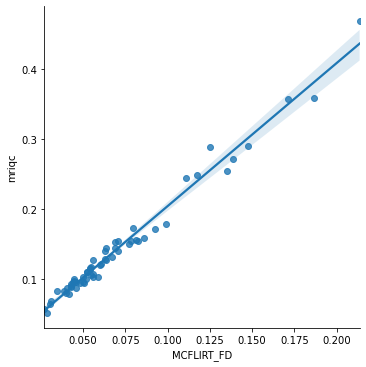

pearson product moment for MCFLIRT and fmriprep r: 0.9749140126235107 p: 1.525505247401248e-39


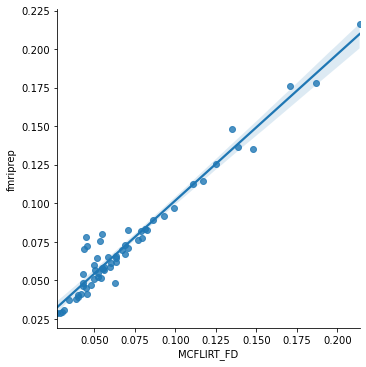

In [39]:
import seaborn as sms
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
exclusions_df.head()


r,p=pearsonr(exclusions_df['MCFLIRT_FD'],exclusions_df['mriqc'])
print("pearson product moment for MCFLIRT and MRIQC r: %s p: %s" %(r,p))
sms.lmplot(x='MCFLIRT_FD',y='mriqc',data=exclusions_df)
plt.show()

r,p=pearsonr(exclusions_df['MCFLIRT_FD'],exclusions_df['fmriprep'])
print("pearson product moment for MCFLIRT and fmriprep r: %s p: %s" %(r,p))
sms.lmplot(x='MCFLIRT_FD',y='fmriprep',data=exclusions_df)


In [44]:
corr_df=exclusions_df[['MCFLIRT_FD','fmriprep','mriqc']]
display(corr_df.corr())

,MCFLIRT_FD,fmriprep,mriqc
MCFLIRT_FD,1.000000,0.974914,0.990047
fmriprep,0.974914,1.000000,0.969009
mriqc,0.990047,0.969009,1.000000


In [9]:

results=exclusions_df.groupby(by='sub').sum().reset_index().rename(columns={"TrialCount_misses": "TotalCount_misses"})
results['Beh_TotalExclusion']=results['TotalCount_misses']>81
results=results[['sub','TotalCount_misses','Beh_TotalExclusion']]


In [10]:
exclusions_df.merge(results,on='sub')
exclusions_df.to_csv('../derivatives/exclusions.csv', index=False)

In [14]:
exclusions_df.groupby(by='sub').sum()

,TrialCount_misses,Max_Abs_motion,FD_mean,FD_exclusion,ABS_exclusion,Beh_TrialExclusion
sub,,,,,,
sub-10017,1.0,4.135335,0.280834,0,0,0
sub-10024,4.0,3.286222,0.333501,0,0,0
sub-10035,33.0,2.748913,0.300442,0,0,0
sub-10041,0.0,8.948181,0.595730,0,4,0
sub-10043,3.0,4.666819,0.334741,0,0,0
sub-10054,13.0,4.730377,0.499728,0,1,0
sub-10059,0.0,3.283416,0.289011,0,0,0
sub-10069,7.0,7.064291,0.586771,0,2,0
sub-10074,4.0,4.583511,0.365633,0,0,0
